# Laboratorio de regresión logística

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 03/10/2026       |
| **Expediente** | 757806           |

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm

In [28]:
datos = pd.read_csv("Default.csv")

print(datos.shape)

(10000, 4)


2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [29]:
datos.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [30]:
datos.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

Son 10000 filas y 4 columnas

default y student traen texto con Yes o No, esas son cualitativas. balance e income son numericas

El describe solo saca balance e income porque las otras dos no son numeros. De los 10000 nomas 333 son default Yes, apenas el 3.3 por ciento, esta bien desbalanceado

In [31]:
datos["default"].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [32]:
for columna in ["default", "student"]:
    datos[columna] = datos[columna].astype("category")

datos.dtypes

default    category
student    category
balance     float64
income      float64
dtype: object

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

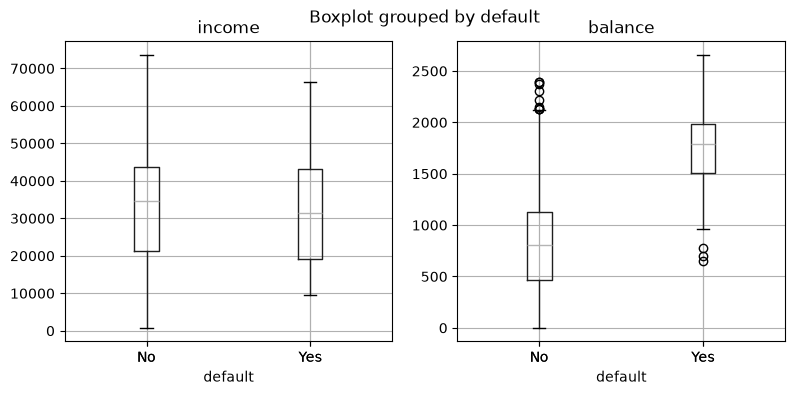

In [33]:
datos.boxplot(column=["income", "balance"], by="default", figsize=(9, 4), sharey=False)
plt.show()

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

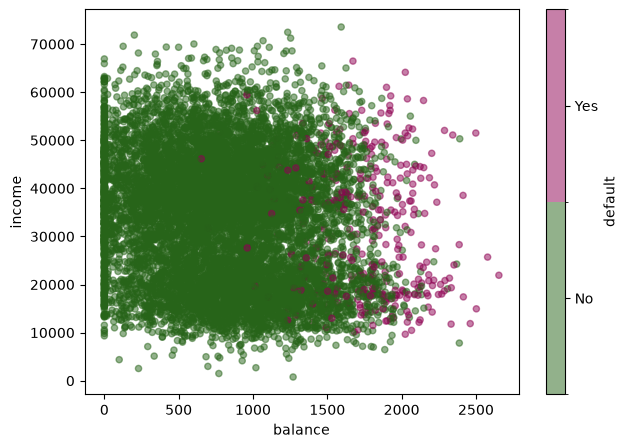

In [34]:
datos.plot.scatter(x="balance", y="income", c="default", colormap="PiYG_r", alpha=0.5, figsize=(7, 5))
plt.show()

In [35]:
datos.groupby("default", observed=True)[["balance", "income"]].mean()

,balance,income
default,,
No,803.94375,33566.166625
Yes,1747.82169,32089.147124


En el balance se ve que los que dejaron de pagar traen un balance mucho mas alto, 1748 contra 804 de los que si pagaron. En el income las dos cajas quedan casi iguales, 33566 contra 32089, ahi no se separa nada

En la dispersion pasa lo mismo, los puntos de default se van todos a la derecha sin importar la altura. El balance es el que va a servir, el income parece que no

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [36]:
y = datos["default"] == "Yes"
x = datos[["balance"]]

print(y.sum(), "de", len(y))

333 de 10000


Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

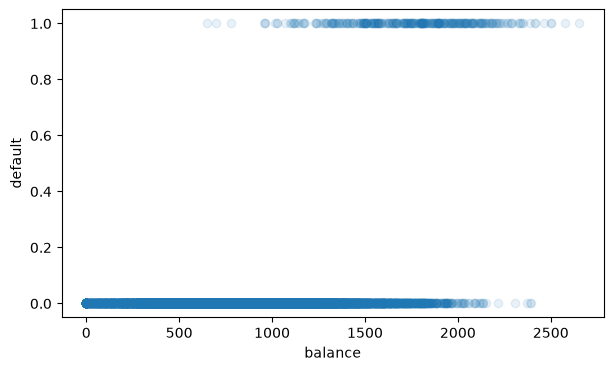

In [37]:
plt.figure(figsize=(7, 4))
plt.scatter(x["balance"], y, alpha=0.1)
plt.xlabel("balance")
plt.ylabel("default")
plt.show()

Se ven solo dos lineas porque la y nomas puede ser 0 o 1. Una recta no sirve aqui, se saldria del rango y daria probabilidades negativas o arriba de 1, por eso se usa la curva logistica

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [38]:
modelo = LogisticRegression()
modelo.fit(x, y)

print("beta0:", modelo.intercept_[0])
print("beta1:", modelo.coef_[0][0])

beta0: -10.65132823650608
beta1: 0.005498915547165412


beta0 sale -10.65 y beta1 0.0055. El beta1 positivo quiere decir que entre mas balance mas probabilidad de dejar de pagar

Esta en log odds, no en probabilidad. Por cada dolar de balance los log odds suben 0.0055, o sea que por cada 100 dolares mas de balance suben 0.55

Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [39]:
p = modelo.predict_proba(x)[:, 1]

print(p[:4])

[0.00130568 0.0021126  0.00859475 0.00043444]


2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [40]:
w = p * (1 - p)

print(w[:4])

[0.00130398 0.00210813 0.00852088 0.00043425]


3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [41]:
V = np.diagflat(w)

print(V.shape)

(10000, 10000)


4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [42]:
# la X necesita la columna de unos para que salga tambien el error del intercepto

X = np.column_stack([np.ones(len(x)), x["balance"]])

cov = np.linalg.inv(X.T @ V @ X)
cov

array([[ 1.30442757e-01, -7.81757265e-05],
       [-7.81757265e-05,  4.85656561e-08]])

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [43]:
se = np.sqrt(np.diag(cov))

print("SE beta0:", se[0])
print("SE beta1:", se[1])

SE beta0: 0.3611685997247462
SE beta1: 0.00022037616946912202


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [44]:
betas = np.r_[modelo.intercept_, modelo.coef_[0]]
z = betas / se

print("z beta0:", z[0])
print("z beta1:", z[1])

z beta0: -29.491290894678194
z beta1: 24.952405518310325


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [45]:
p_value = 2 * (1 - norm.cdf(abs(z)))

pd.DataFrame({"coef": betas, "SE": se, "z": z, "p_value": p_value},
             index=["intercepto", "balance"])

,coef,SE,z,p_value
intercepto,-10.651328,0.361169,-29.491291,0.0
balance,0.005499,0.000220,24.952406,0.0


¿Es significativa la relación de los factores con la variable de respuesta?

Si. El z del balance sale 24.95 y el p value queda en practicamente 0, muy abajo de 0.05, entonces el balance si tiene relacion con dejar de pagar

Se ve tambien comparando el error estandar contra el coeficiente, 0.00022 contra 0.0055, el coeficiente es como 25 veces su propio error, por eso el z sale tan grande

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [46]:
datos["student_num"] = (datos["student"] == "Yes").astype(int)

xs = datos[["student_num"]]

modelo_s = LogisticRegression()
modelo_s.fit(xs, y)

print("beta0:", modelo_s.intercept_[0])
print("beta1:", modelo_s.coef_[0][0])

beta0: -3.5025724918531327
beta1: 0.39620888476865457


In [47]:
ps = modelo_s.predict_proba(xs)[:, 1]
ws = ps * (1 - ps)
Vs = np.diagflat(ws)

Xs = np.column_stack([np.ones(len(xs)), xs["student_num"]])

cov_s = np.linalg.inv(Xs.T @ Vs @ Xs)
se_s = np.sqrt(np.diag(cov_s))

betas_s = np.r_[modelo_s.intercept_, modelo_s.coef_[0]]
z_s = betas_s / se_s
p_value_s = 2 * (1 - norm.cdf(abs(z_s)))

pd.DataFrame({"coef": betas_s, "SE": se_s, "z": z_s, "p_value": p_value_s},
             index=["intercepto", "student"])

,coef,SE,z,p_value
intercepto,-3.502572,0.070661,-49.568381,0.000000
student,0.396209,0.115221,3.438698,0.000585


In [48]:
# para comparar, el porcentaje de default crudo en cada grupo

pd.crosstab(datos["student"], datos["default"], normalize="index")

default,No,Yes
student,,
No,0.970805,0.029195
Yes,0.956861,0.043139


El beta de student sale 0.396 con error estandar 0.115, z de 3.44 y p value de 0.00059. Si es significativo pero mucho menos que el balance, ahi el z era 25 y aqui apenas 3.4

El signo positivo dice que los estudiantes caen mas en default y en crudo si es cierto, 4.3 por ciento de los estudiantes contra 2.9 de los que no lo son

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [49]:
Xm = datos[["balance", "income", "student_num"]]

modelo_m = LogisticRegression()
modelo_m.fit(Xm, y)

print("beta0:", modelo_m.intercept_[0])
print("betas:", modelo_m.coef_[0])

beta0: -10.901811601515222
betas: [ 5.73060606e-03  3.96189935e-06 -6.12564507e-01]


In [50]:
pm = modelo_m.predict_proba(Xm)[:, 1]
wm = pm * (1 - pm)
Vm = np.diagflat(wm)

Xm_unos = np.column_stack([np.ones(len(Xm)), Xm])

cov_m = np.linalg.inv(Xm_unos.T @ Vm @ Xm_unos)
se_m = np.sqrt(np.diag(cov_m))

betas_m = np.r_[modelo_m.intercept_, modelo_m.coef_[0]]
z_m = betas_m / se_m
p_value_m = 2 * (1 - norm.cdf(abs(z_m)))

pd.DataFrame({"coef": betas_m, "SE": se_m, "z": z_m, "p_value": p_value_m},
             index=["intercepto", "balance", "income", "student"])

,coef,SE,z,p_value
intercepto,-10.901812,0.493158,-22.106102,0.000000
balance,0.005731,0.000232,24.735500,0.000000
income,0.000004,0.000008,0.482661,0.629336
student,-0.612565,0.236394,-2.591287,0.009562


In [51]:
# balance promedio de cada grupo

datos.groupby("student", observed=True)["balance"].mean()

student
No     771.770402
Yes    987.818239
Name: balance, dtype: float64

El balance sigue siendo el fuerte, coeficiente 0.00573 con z de 24.7 y p value de 0

El income sale con p value de 0.63, ese no es significativo y se puede sacar del modelo. Ya se veia desde el boxplot donde las dos cajas eran iguales

Lo raro es el student, cambio de signo. Solo valia 0.396 positivo y ahora es -0.613 con p value de 0.0096. Pasa porque los estudiantes traen mas balance, 988 contra 772 de los demas. Si no controlas el balance parece que ser estudiante es malo, pero comparando dos personas con el mismo balance el estudiante cae menos en default. Son dos preguntas distintas y por eso dan respuestas distintas

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

- Un filtro de spam que manda a la basura un correo que si era importante, el usuario nunca lo ve
- Un examen antidoping que sale positivo en un atleta limpio, lo suspenden sin haber hecho nada

En los dos el daño de acusar a alguien que no era es mas grande que dejar pasar uno

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

- Una prueba de cancer que sale negativa en alguien que si lo tiene, se va a su casa sin tratamiento
- El detector de fraude del banco que deja pasar una transaccion robada

Aqui es mejor pasarse de desconfiado, el falso positivo nomas cuesta revisar otra vez y el falso negativo cuesta la salud o el dinero



## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3